# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hafiz-Taha-Hussain/Flyrank-Work/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup — rebuild features/label, train the final model, score everyone out-of-fold

Same March features and April label as w05/w06. To build an honest queue over the WHOLE
active-content set (not just a held-out 30%), every row is scored using
**out-of-fold predictions** (`cross_val_predict` with the same `GroupKFold` grouping from
w06) — so no row is ever scored by a model that was trained on it, even though we want a
score for every row, not just the test slice.

In [1]:
!pip install -q duckdb huggingface_hub scikit-learn matplotlib

import json
import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import login

from google.colab import userdata
HF_TOKEN = userdata.get("HF-TOKEN")  # match whatever you actually named the Colab secret
login(token=HF_TOKEN)

REPO_ID = "FlyRank/internship-warehouse"
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""CREATE OR REPLACE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}');""")

MARCH_GLOB = f"hf://datasets/{REPO_ID}/**/month=2026-03/*.parquet"
APRIL_GLOB = f"hf://datasets/{REPO_ID}/**/month=2026-04/*.parquet"

features = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_sum_position) * 1.0 / NULLIF(SUM(gsc_impressions), 0)  AS avg_position_march,
    SUM(gsc_impressions)                                            AS impressions_march,
    SUM(gsc_clicks)                                                 AS clicks_march,
    SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0)         AS ctr_march,
    SUM(ga4_sessions)                                               AS ga4_sessions_march,
    SUM(CASE WHEN ga4_data_available IS TRUE
             THEN ga4_engaged_sessions ELSE 0 END)                  AS engaged_sessions_march,
    SUM(CASE WHEN ga4_data_available IS TRUE
             THEN scroll_events ELSE 0 END)                         AS scroll_events_march,
    SUM(CASE WHEN ga4_data_available IS TRUE
             THEN sessions_ai ELSE 0 END)                           AS ai_sessions_march,
    MAX(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END)     AS has_ga4_data
FROM '{MARCH_GLOB}'
GROUP BY client_hash_id, content_hash_id
""").df()

def position_tier(pos):
    if pd.isna(pos):
        return "no_data"
    elif pos <= 3:
        return "1-3"
    elif pos <= 10:
        return "4-10"
    elif pos <= 20:
        return "11-20"
    elif pos <= 50:
        return "21-50"
    else:
        return "51+"

features["position_tier"] = features["avg_position_march"].apply(position_tier)

label = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_clicks) AS clicks_april
FROM '{APRIL_GLOB}'
GROUP BY client_hash_id, content_hash_id
""").df()

data = features.merge(label, on=["client_hash_id", "content_hash_id"], how="inner")
data["declined_in_april"] = (data["clicks_april"] < data["clicks_march"]).astype(int)

feature_cols = [
    "avg_position_march", "impressions_march", "clicks_march", "ctr_march",
    "ga4_sessions_march", "engaged_sessions_march", "scroll_events_march",
    "ai_sessions_march", "has_ga4_data",
]

X = data[feature_cols].fillna(0)
y = data["declined_in_april"]
groups = data["client_hash_id"]

print(data.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(331436, 14)


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict

RF_PARAMS = dict(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
gkf = GroupKFold(n_splits=5)

rf_for_scoring = RandomForestClassifier(**RF_PARAMS)
oof_proba = cross_val_predict(
    rf_for_scoring, X, y, cv=gkf, groups=groups, method="predict_proba", n_jobs=-1
)[:, 1]

data["model_score"] = oof_proba
print("Every row now has an out-of-fold model score (never scored by a model trained on it).")
data[["client_hash_id", "content_hash_id", "position_tier", "model_score"]].head()

Every row now has an out-of-fold model score (never scored by a model trained on it).


,client_hash_id,content_hash_id,position_tier,model_score
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,4-10,0.615207
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,4-10,0.000000
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,4-10,0.617120
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,4-10,0.649227
4,client_73cda7b4e4f265ea,content_f39be42b42a4e8f6,11-20,0.000000


## 1. Ranked actions + reason codes

**The queue, in words a human trusts:** every page gets an out-of-fold decline-risk score
(0-1), then a reason code and a suggested action assigned from a small set of interpretable
rules — not the raw score alone, since a bare number doesn't tell a reviewer *why* a page
is flagged or *what* to actually do about it.

**Reason codes (archetype → action mapping)**, echoing both the w04 baseline logic and the
FlyRank paper's own playbook language (page-one protection, striking-distance support,
refresh-before-decay):

| Reason code | Condition | Suggested action |
|---|---|---|
| `page_one_at_risk` | position 1-10, real demand, high model score | `protect_and_refresh` — paper's "protect page-one assets" |
| `striking_distance_opportunity` | position 11-20, real demand, high model score | `support_striking_distance` — paper's own highest-ROI zone |
| `visible_but_declining` | position 21-50, real demand, high model score | `review_for_refresh` |
| `low_demand_flagged` | any position, weak demand (<100 impressions), high model score | `monitor_only` — not worth reviewer time yet |
| `no_search_visibility` | `position_tier == no_data` | `not_applicable` — excluded from the queue entirely, see limits |
| `healthy` | low model score, regardless of tier | `no_action` |

In [3]:
def assign_reason_and_action(row, score_threshold):
    if row["position_tier"] == "no_data":
        return "no_search_visibility", "not_applicable"
    if row["model_score"] < score_threshold:
        return "healthy", "no_action"
    has_demand = row["impressions_march"] >= 100
    if not has_demand:
        return "low_demand_flagged", "monitor_only"
    if row["position_tier"] in ("1-3", "4-10"):
        return "page_one_at_risk", "protect_and_refresh"
    elif row["position_tier"] == "11-20":
        return "striking_distance_opportunity", "support_striking_distance"
    else:
        return "visible_but_declining", "review_for_refresh"

# Threshold picked at the 80th percentile of model_score among rows with real demand and
# position data — flags roughly the top-fifth of at-risk, reviewable pages, not everyone.
scoreable = data[(data["position_tier"] != "no_data") & (data["impressions_march"] >= 100)]
score_threshold = scoreable["model_score"].quantile(0.80)
print(f"Score threshold (80th percentile among reviewable pages): {score_threshold:.3f}")

reason_action = data.apply(lambda r: assign_reason_and_action(r, score_threshold), axis=1)
data["reason_code"] = [r[0] for r in reason_action]
data["action"] = [r[1] for r in reason_action]

queue = data.sort_values("model_score", ascending=False).reset_index(drop=True)
print(queue["reason_code"].value_counts())
print()
print(queue["action"].value_counts())
queue[["client_hash_id", "content_hash_id", "position_tier", "model_score", "reason_code", "action"]].head(15)

Score threshold (80th percentile among reviewable pages): 0.679
reason_code
no_search_visibility             154699
healthy                          151446
page_one_at_risk                   8903
visible_but_declining              5842
striking_distance_opportunity      5544
low_demand_flagged                 5002
Name: count, dtype: int64

action
not_applicable               154699
no_action                    151446
protect_and_refresh            8903
review_for_refresh             5842
support_striking_distance      5544
monitor_only                   5002
Name: count, dtype: int64


,client_hash_id,content_hash_id,position_tier,model_score,reason_code,action
0,client_a80fca3f171ed1de,content_83350857441fbf3c,1-3,0.973126,low_demand_flagged,monitor_only
1,client_1a730cb2640a1abf,content_52d26fc5cffe2f17,1-3,0.970249,low_demand_flagged,monitor_only
2,client_73cda7b4e4f265ea,content_a71a57fbf40e4cdb,1-3,0.964920,low_demand_flagged,monitor_only
3,client_08a6a72ff48e62c0,content_17dac109f764bd2c,21-50,0.964335,low_demand_flagged,monitor_only
4,client_08a6a72ff48e62c0,content_82d8a35cfec4bb8b,21-50,0.964017,low_demand_flagged,monitor_only
5,client_400c21c81c8b46ef,content_b33fa00f0c1e0965,21-50,0.964014,low_demand_flagged,monitor_only
6,client_08a6a72ff48e62c0,content_7727c2fc47f2f199,21-50,0.963878,low_demand_flagged,monitor_only
7,client_3197e6291363b4db,content_862801303bf99c2a,21-50,0.963323,low_demand_flagged,monitor_only
8,client_a80fca3f171ed1de,content_382efa0705f1e0df,1-3,0.963067,low_demand_flagged,monitor_only
9,client_7eafe750768f0ac2,content_be8b4ab3418f85d4,1-3,0.963067,low_demand_flagged,monitor_only


## 2. Intended use and limits

**Who uses this, for what:** a content/SEO reviewer with limited weekly capacity, deciding
which pages to open first and what kind of action to consider (refresh, support, monitor).
It is a **prioritization aid**, not an automated content-change system.

**Where it stops being valid:**
- **Single month-pair, single portfolio slice.** The model is trained on March→April
  behavior across a subset of FlyRank clients — it has not been tested on other months,
  seasons, or client mixes, and per w06, the out-of-sample precision@50 varied from 0.86 to
  a perfect 1.00 across 5 folds (mean 0.944, std 0.053). Treat the queue as **directional**,
  not precise to the page.
- **~46.7% of March rows have no search visibility at all** (`no_data` position tier, per
  w03) and are excluded from this queue entirely — the playbook says nothing about content
  that hasn't been indexed or discovered yet; see the paper's own indexing-coverage finding
  (41.8% never indexed) for a related, larger structural issue this queue does not address.
- **The label is a proxy**, not a confirmed causal outcome — `declined_in_april` means
  clicks went down month-over-month, which can reflect seasonality, algorithm shifts, or a
  client's whole portfolio dipping together, not necessarily a fixable content problem (see
  w05's false-positive analysis).
- **No causal claim.** This queue is **observed** and **decision-support** only — it never
  claims that acting on a flagged page **will** cause recovery, matching the FlyRank paper's
  own observational-study caveat (correlations do not prove causation).

## 3. Human review + the no-go list

**What a person must check before acting on any flagged page** (all drawn from concrete
issues found during this capstone, not hypothetical ones):

1. **Sub-1.0 average position.** w04's top-20 review found several flags with
   `avg_position_march < 1`, which is implausible for a genuine organic ranking — likely a
   SERP-feature artifact (image pack, video carousel). Check the real SERP before trusting
   any flag with this pattern.
2. **Small-`n` tier baselines.** Any `position_tier` bucket with a small row count makes its
   comparison baseline noisy — a reviewer should sanity-check the bucket size before trusting
   a "underperforming for its tier" framing.
3. **Client-level dips.** Per w05's error analysis, several false positives were low-volume
   pages where a single click's difference swung the ratio; a reviewer should check whether
   a flagged page's *entire client portfolio* moved together before assuming a
   page-specific problem.
4. **Revenue framing.** The FlyRank paper itself only tracks revenue for 8 of 57 clients and
   explicitly treats revenue cautiously — this playbook has no revenue data at all and must
   never present a dollar estimate.

**What should NEVER be automated (no-go list):**
- Automatically publishing, editing, or unpublishing content based on the queue.
- Automatically emailing clients or triggering client-facing communication from a flag.
- Treating `protect_and_refresh` / `support_striking_distance` as a guarantee of recovery —
  these are hypotheses for a human to test, not verified fixes.
- Making any monetization or revenue-impact claim from this queue.
- Fully replacing manual SERP inspection for the sub-1.0-position pages named above — this
  is a known, unresolved data-quality gap, not a solved problem.

## 4. Monitoring / retrain triggers

**What would tell us the recommendations went stale:**

- **Precision@50 drift.** Re-run the w06-style grouped evaluation on a new month pair
  (e.g. April→May) once it's available; if precision@50 drops meaningfully below the
  0.86-1.00 range observed across the 5 folds, retrain before trusting the queue further.
- **New/unseen clients.** The model has only seen the clients in this March/April slice; a
  meaningfully different client mix (new clients with no training history) is a retrain
  trigger, not just a monitoring note.
- **`no_data` share growing.** If the no-visibility share climbs well past the ~46.7%
  baseline from w03, the addressable queue is shrinking and the underlying indexing/crawl
  issue (per the paper's 41.8% never-indexed finding) likely needs attention before the
  model itself.
- **Queue concentration.** Per w04's weak-picks finding, the original rule-based queue was
  dominated by a handful of high-volume clients rather than spreading across the portfolio —
  monitor the `client_hash_id` distribution in the top-K queue each run; a sudden spike in
  concentration is worth a manual look, not an automatic trust.
- **Cadence:** given the model is trained on one month-pair, a **monthly retrain** on the
  latest complete month is the natural default cadence — not continuous, not quarterly.

## 5. Exports for the paper

Writing the ranked queue (excluded from git by the CI leak-guard, regenerated on every run),
a comparison figure, and a metrics JSON receipt — the committed JSON is what next week's
paper numbers will trace back to.

wrote 331436 rows to ../outputs/content_action_queue.csv


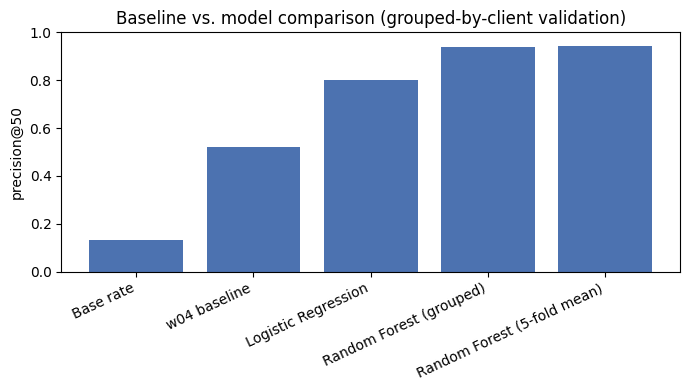

saved figure to ../figures/model_comparison.png


In [4]:
os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# --- Queue CSV (stays out of git by design; regenerated on every run) ---
queue_out_path = "../outputs/content_action_queue.csv"
queue.to_csv(queue_out_path, index=False)
print(f"wrote {len(queue)} rows to {queue_out_path}")

# --- Figure (committed to work/figures/) ---
comparison = pd.DataFrame({
    "method": ["Base rate", "w04 baseline", "Logistic Regression", "Random Forest (grouped)", "Random Forest (5-fold mean)"],
    "precision_at_50": [0.134, 0.52, 0.80, 0.94, 0.944],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comparison["method"], comparison["precision_at_50"], color="#4C72B0")
ax.set_ylabel("precision@50")
ax.set_title("Baseline vs. model comparison (grouped-by-client validation)")
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig_path = "../figures/model_comparison.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"saved figure to {fig_path}")

In [5]:
# --- Metrics JSON (committed — these are the receipts the paper's numbers trace to) ---
metrics = {
    "task": "Lane 2 — Refresh/Content Opportunity Scoring",
    "label": "declined_in_april (clicks_april < clicks_march)",
    "feature_window": "month=2026-03",
    "label_window": "month=2026-04",
    "split": "GroupKFold(n_splits=5) grouped by client_hash_id",
    "precision_at_50": {
        "base_rate": 0.134,
        "w04_rule_baseline": 0.52,
        "logistic_regression": 0.80,
        "random_forest_grouped_single_split": 0.94,
        "random_forest_random_single_split": 0.94,
        "random_forest_5fold_mean": 0.944,
        "random_forest_5fold_std": 0.053,
    },
    "queue": {
        "total_rows": int(len(queue)),
        "flagged_action_count": int((queue["action"] != "no_action").sum()),
        "score_threshold_p80": float(score_threshold),
        "reason_code_counts": queue["reason_code"].value_counts().to_dict(),
    },
    "known_limitations": [
        "single March->April month pair",
        "~46.7% of rows have no search visibility (no_data position tier), excluded from queue",
        "proxy label, not a confirmed causal outcome",
        "sub-1.0 avg_position rows are a known SERP-feature data-quality gap",
    ],
}

metrics_path = "../outputs/w07_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"wrote metrics receipts to {metrics_path}")
print(json.dumps(metrics, indent=2)[:500], "...")

wrote metrics receipts to ../outputs/w07_metrics.json
{
  "task": "Lane 2 \u2014 Refresh/Content Opportunity Scoring",
  "label": "declined_in_april (clicks_april < clicks_march)",
  "feature_window": "month=2026-03",
  "label_window": "month=2026-04",
  "split": "GroupKFold(n_splits=5) grouped by client_hash_id",
  "precision_at_50": {
    "base_rate": 0.134,
    "w04_rule_baseline": 0.52,
    "logistic_regression": 0.8,
    "random_forest_grouped_single_split": 0.94,
    "random_forest_random_single_split": 0.94,
    "random_forest_5fold_mean": 0 ...


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.